In [9]:
!pip install pandas numpy matplotlib tensorflow scikit-learn pillow opencv-python

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn
import cv2
from PIL import Image

print("All libraries installed successfully!")
print("TensorFlow version:", tf.__version__)

All libraries installed successfully!
TensorFlow version: 2.21.0


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [14]:
df = pd.read_csv("socal2.csv")

In [15]:
df.head()

,image_id,street,citi,n_citi,bed,bath,sqft,price
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1.0,1082,350000
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3.0,2547,385100


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15474 entries, 0 to 15473
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   image_id  15474 non-null  int64  
 1   street    15474 non-null  object 
 2   citi      15474 non-null  object 
 3   n_citi    15474 non-null  int64  
 4   bed       15474 non-null  int64  
 5   bath      15474 non-null  float64
 6   sqft      15474 non-null  int64  
 7   price     15474 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 967.3+ KB


In [17]:
df.describe()

,image_id,n_citi,bed,bath,sqft,price
count,15474.000000,15474.000000,15474.000000,15474.000000,15474.000000,1.547400e+04
mean,7736.500000,216.597518,3.506398,2.453251,2173.913209,7.031209e+05
std,4467.103368,112.372985,1.034838,0.958742,1025.339617,3.769762e+05
min,0.000000,0.000000,1.000000,0.000000,280.000000,1.950000e+05
25%,3868.250000,119.000000,3.000000,2.000000,1426.000000,4.450000e+05
50%,7736.500000,222.500000,3.000000,2.100000,1951.000000,6.390000e+05
75%,11604.750000,315.000000,4.000000,3.000000,2737.750000,8.349750e+05
max,15473.000000,414.000000,12.000000,36.000000,17667.000000,2.000000e+06


In [18]:
df.isnull().sum()

image_id    0
street      0
citi        0
n_citi      0
bed         0
bath        0
sqft        0
price       0
dtype: int64

In [19]:
df = df.dropna()

In [20]:
df.shape

(15474, 8)

In [21]:
df = df.head(500)

In [22]:
df.shape

(500, 8)

In [23]:
X_tabular = df[['bed', 'bath', 'sqft', 'n_citi']]

In [24]:
y = df['price']

In [25]:
X_tabular.head()

,bed,bath,sqft,n_citi
0,3,2.0,1560,317
1,3,2.0,713,48
2,3,1.0,800,152
3,3,1.0,1082,48
4,4,3.0,2547,55


In [26]:
y.head()

0    201900
1    228500
2    273950
3    350000
4    385100
Name: price, dtype: int64

In [27]:
scaler = StandardScaler()

X_tabular = scaler.fit_transform(X_tabular)

In [28]:
X_tabular

array([[-0.5343141 , -0.54719509, -0.72230937,  0.91985542],
       [-0.5343141 , -0.54719509, -1.60134434, -1.19462824],
       [-0.5343141 , -1.58041844, -1.51105386, -0.3771327 ],
       ...,
       [ 0.43364623, -1.4770961 ,  0.06332165,  0.05519667],
       [ 0.43364623, -0.44387275,  1.29106472,  1.65088508],
       [-0.5343141 , -0.54719509, -0.49813988,  0.05519667]],
      shape=(500, 4))

In [29]:
X_tabular.shape

(500, 4)

In [30]:
cnn = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17308\3054585325.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [37]:
image_features = []

In [41]:
img_path = os.path.join(
    "housing_dataset_with_images",
    "socal2",
    "socal_pics",
    str(df.iloc[0]["image_id"]) + ".jpg"
)

print(img_path)
print(os.path.exists(img_path))

housing_dataset_with_images\socal2\socal_pics\0.jpg
True


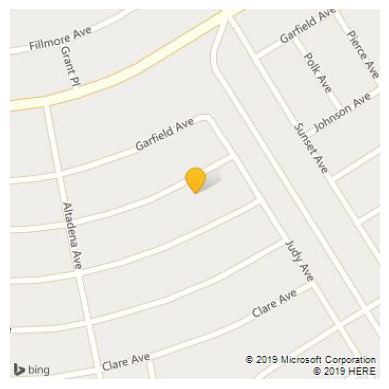

In [42]:
img = image.load_img(img_path)

plt.imshow(img)

plt.axis("off")

plt.show()

In [43]:
img = image.load_img(
    img_path,
    target_size=(224, 224)
)

In [44]:
img_array = image.img_to_array(img)

print(img_array.shape)

(224, 224, 3)


In [45]:
img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)

(1, 224, 224, 3)


In [46]:
img_array = preprocess_input(img_array)

In [47]:
features = cnn.predict(img_array, verbose=0)

print(features.shape)

(1, 1280)


In [48]:
features = features.flatten()

print(features.shape)

(1280,)


In [50]:
image_features = []
valid_indices = []

In [51]:
image_features = []
valid_indices = []

for index, row in df.iterrows():

    img_path = os.path.join(
        "housing_dataset_with_images",
        "socal2",
        "socal_pics",
        str(row["image_id"]) + ".jpg"
    )

    if os.path.exists(img_path):

        img = image.load_img(img_path, target_size=(224,224))

        img_array = image.img_to_array(img)

        img_array = np.expand_dims(img_array, axis=0)

        img_array = preprocess_input(img_array)

        features = cnn.predict(img_array, verbose=0)

        image_features.append(features.flatten())

        valid_indices.append(index)

print("Total Images Processed:", len(image_features))

Total Images Processed: 500


In [52]:
image_features = np.array(image_features)

print(image_features.shape)

(500, 1280)


In [53]:
df = df.loc[valid_indices].reset_index(drop=True)

In [55]:
X_tabular = df[['bed', 'bath', 'sqft', 'n_citi']]
scaler = StandardScaler()

X_tabular = scaler.fit_transform(X_tabular)
print(X_tabular.shape)

(500, 4)


In [56]:
X = np.concatenate((X_tabular, image_features), axis=1)

print(X.shape)

(500, 1284)


In [57]:
y = df['price']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (400, 1284)
Testing : (100, 1284)


In [60]:
model = Sequential()

model.add(Dense(
    512,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

model.add(Dense(
    256,
    activation='relu'
))

model.add(Dense(
    64,
    activation='relu'
))

model.add(Dense(1))

C:\Users\lenovo\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         657,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 805,761 (3.07 MB)

 Trainable params: 805,761 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [63]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 666928611328.0000 - mae: 670938.1875 - val_loss: 742643335168.0000 - val_mae: 713532.4375
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 666533494784.0000 - mae: 670656.0000 - val_loss: 741808144384.0000 - val_mae: 712948.9375
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 665064964096.0000 - mae: 669561.2500 - val_loss: 739083485184.0000 - val_mae: 711042.1250
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 660855062528.0000 - mae: 666497.4375 - val_loss: 732179529728.0000 - val_mae: 706186.2500
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 651368726528.0000 - mae: 659334.0000 - val_loss: 717410533376.0000 - val_mae: 695683.1875
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 632383733760.0000 - mae: 644633.8125 - val_loss: 689257709568.0000 - val_mae: 675201.3125
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 598392111104.0000 - mae: 617406.3750 - val_loss

In [64]:
predictions = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [65]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 481474.3125


In [66]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 549866.666252829


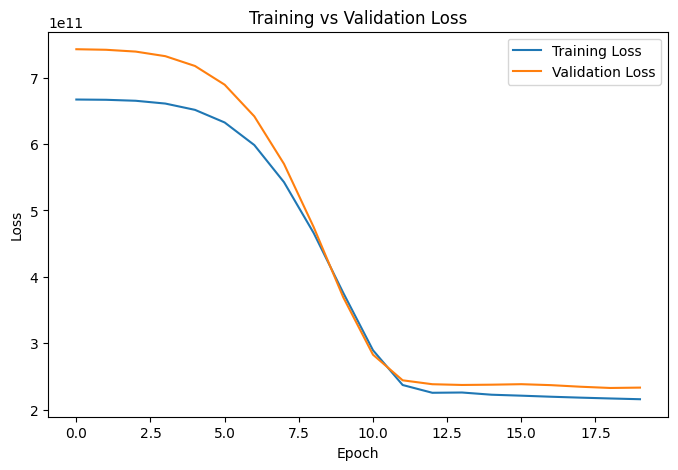

In [67]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [68]:
model.save("house_price_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


In [69]:
print("Actual Price:")
print(y_test.iloc[0])

print("\nPredicted Price:")
print(predictions[0][0])

Actual Price:
1150000

Predicted Price:
550452.1
